# 05 · Continuous HMS Simulation + Event Extraction + Calibration

**Author:** Salvador Navas  
**Basin:** Río Besaya — Cantabria

## Continuous simulation methodology
1. Prepare the daily AMR time series by subbasin (Notebook 02)
2. Write `.gage` and `.met` files for continuous simulation (Oct 2008 – Dec 2012)
3. Run HEC-HMS in continuous mode when the external binary is available
4. Read the resulting continuous hydrograph from DSS when available
5. Compare with observed streamflow (station 1237 Torrelavega)
6. Calibration metrics: NSE, KGE, volumetric bias
7. Extract above-threshold events for the downscaling step

**Execution note.** If HEC-HMS/DSS output is unavailable, the notebook can load a
precomputed CORDEX/HMS ensemble only as a proxy dataset. In that mode calibration
metrics are not interpreted as model performance for the Besaya HMS setup.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from pyhydra.modeling.hydrology.hec_hms import (
    read_gages, read_basin,
    generate_gage, fill_gage,
    generate_met, generate_control, generate_run, generate_py,
    run_hms_script, read_dss6_timeseries,
)
from pyhydra.climate.time_series.events import (
    extract_discharge_events,
    extract_concurrent_events,
)

# Resolve repo root: Jupyter sets cwd to the notebook dir;
# in Docker/script contexts cwd=/workspace (one level up)
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent.parent.parent if _cwd.name == 'los_corrales_buelna' else _cwd
DATA_ROOT = REPO_ROOT / 'data' / 'pilot_cases' / 'los_corrales_buelna'
PROC_DIR  = DATA_ROOT / 'processed'
HMS_DIR   = DATA_ROOT / 'models' / 'hec_hms'
OUT_DIR   = PROC_DIR / 'hms_continuous'
OUT_DIR.mkdir(parents=True, exist_ok=True)

HEC_HMS_BIN = Path('/workspace/data/hms/HEC-HMS-4.13/hec-hms.sh')
NAME_MODEL  = 'Project_1'
NAME_BASIN  = 'Modelo_Besaya'
PATH_MODEL  = str(HMS_DIR)

# Simulation period (corresponds to the original Besaya model control run)
SIM_START = '1 October 2008, 00:00'
SIM_END   = '31 December 2012, 24:00'
TIME_STEP = 1440   # minutos (diario, igual que los datos disponibles)

print(f'Periodo de simulación: {SIM_START} → {SIM_END}')

Periodo de simulación: 1 October 2008, 00:00 → 31 December 2012, 24:00


## 1. Load daily AMR by subbasin

In [2]:
pma = pd.read_csv(PROC_DIR / 'pma_idw_daily.csv', index_col=0, parse_dates=True)
pma = pma.clip(lower=0)

# Filter simulation period
pma_sim = pma.loc['2008-10-01':'2012-12-31']

print(f'PMA shape: {pma.shape}')
print(f'PMA simulación: {pma_sim.shape}  '
      f'({pma_sim.index[0].date()} → {pma_sim.index[-1].date()})')

PMA shape: (15433, 53)
PMA simulación: (1553, 53)  (2008-10-01 → 2012-12-31)


## 2. HMS file generation for continuous simulation

In [3]:
basin_lines = read_basin(PATH_MODEL, f'{NAME_BASIN}.basin')
subbasins   = [l.split(':')[1].strip() for l in basin_lines
               if l.strip().startswith('Subbasin:')]

CTRL_CONT  = 'Control_Continuous'
MET_CONT   = 'Met_Continuous'
RUN_CONT   = 'Run_Continuous'

# Control
generate_control(
    name_model=NAME_MODEL, path_model=PATH_MODEL,
    name_control=CTRL_CONT,
    start_time=SIM_START, end_time=SIM_END,
    time_interval=TIME_STEP,
)

# Un gage por subcuenca con la PMA interpolada
gage_names = []
for sb in subbasins:
    gage_name = f'Gage_{sb}'
    gage_names.append(gage_name)

    generate_gage(
        path_model=PATH_MODEL, name_model=NAME_MODEL,
        name_gage=gage_name,
        start_time=SIM_START, end_time=SIM_END,
        time_interval=TIME_STEP,
    )

    # Usar PMA de esa subcuenca si existe, si no usar media de todas
    if sb in pma_sim.columns:
        values = pma_sim[sb].fillna(0).values
    else:
        values = pma_sim.mean(axis=1).fillna(0).values

    fill_gage(
        path_model=PATH_MODEL, name_model=NAME_MODEL,
        name_gage=gage_name, values=values,
    )

# Met
generate_met(
    name_met=MET_CONT, names_sbasin=subbasins, names_gage=gage_names,
    path_model=PATH_MODEL, name_basin=NAME_BASIN,
)

# Run
generate_run(
    name_model=NAME_MODEL, path_model=PATH_MODEL,
    name_run=RUN_CONT, name_basin=NAME_BASIN,
    name_met=MET_CONT, name_control=CTRL_CONT,
)

generate_py(PATH_MODEL, NAME_MODEL, [RUN_CONT])
print('Archivos HMS generados para simulación continua')

✓ Control_Continuous.control created and registered in Project_1.hms.
✓ Met_Continuous.met written.
✓ Run 'Run_Continuous' added to Project_1.run.
✓ compute_current.py written to /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/los_corrales_buelna/models/hec_hms/scripts.
Archivos HMS generados para simulación continua


## 3. HEC-HMS execution

In [ ]:
# ── Load HMS simulated streamflow series (calibration 2008-2012) ────────────
# Project_1.dss contains Run_1 (calibrated continuous simulation)
dss_path = HMS_DIR / 'Project_1.dss'
Q_sim = None

if HEC_HMS_BIN.exists():
    ret = run_hms_script(PATH_MODEL, NAME_MODEL, [RUN_CONT],
                         hms_dir=str(HEC_HMS_BIN.parent))
    print(f'HEC-HMS retornó: {ret}')

if dss_path.exists():
    try:
        # read_dss6_timeseries returns DataFrame with columns 'datetime' and 'value'.
        # pathname_prefix identifies the series; monthly date blocks found automatically.
        df_dss = read_dss6_timeseries(
            str(dss_path),
            pathname_prefix='//OUTLET/FLOW',
        )
        Q_sim = pd.Series(
            df_dss['value'].values,
            index=pd.to_datetime(df_dss['datetime']),
            name='Q_sim',
        ).dropna()
        print(f'Caudal simulado (DSS): {len(Q_sim)} pasos')
    except Exception as e:
        print(f'DSS no legible: {e}')

# ── Alternativa: serie CC pre-calculada (10 modelos CORDEX) ─────────────────────
CC_HMS_DIR = DATA_ROOT / 'processed' / 'cc_hms_results'
if Q_sim is None and CC_HMS_DIR.exists():
    cc_files = sorted(CC_HMS_DIR.glob('Caudal_*_rcp45_2041_2070.csv'))
    if cc_files:
        cc_series = {}
        for f in cc_files:
            model = f.stem.replace('Caudal_', '').replace('_r1i1p1_rcp45_2041_2070', '')
            df = pd.read_csv(f, index_col=0, parse_dates=True)
            # Clip negative values — physically impossible for discharge
            series = df.iloc[:, 0].clip(lower=0)
            cc_series[model] = series
        Q_cc_ensemble = pd.DataFrame(cc_series).clip(lower=0)
        print(f'\nEnsamble CC RCP4.5 2041-2070: {Q_cc_ensemble.shape}')
        print(Q_cc_ensemble.describe().round(1))


## 4. Load observed streamflow (station 1237 Torrelavega)

In [5]:
flow_df = pd.read_csv(PROC_DIR / 'flow_daily.csv', index_col=0, parse_dates=True)

# Seleccionar columna de Torrelavega (la principal)
Q_obs_col = flow_df.columns[0]
Q_obs = flow_df[Q_obs_col].rename('Q_obs')

Q_threshold = float(Q_obs.quantile(0.90))   # m³/s — umbral P90 para separación de eventos

print(f'Aforo observado: {Q_obs_col}')
print(f'Periodo: {Q_obs.first_valid_index()} → {Q_obs.last_valid_index()}')
print(f'Qmed = {Q_obs.mean():.2f} m³/s   Qmax = {Q_obs.max():.1f} m³/s')
print(f'Umbral P90 = {Q_threshold:.1f} m³/s')

Aforo observado: 1237
Periodo: 2000-10-01 00:00:00 → 2008-09-30 00:00:00
Qmed = 11.67 m³/s   Qmax = 285.1 m³/s
Umbral P90 = 24.5 m³/s


## 5. Calibration metrics

Metrics are meaningful only when `Q_sim` comes from the continuous HEC-HMS run
for the same period and outlet as the observations. If the notebook has fallen
back to a climate-ensemble proxy, the plots remain useful for checking data
availability, but NSE/KGE/bias are not reported as calibration scores.


In [6]:
def nse(obs, sim):
    """Nash-Sutcliffe Efficiency."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    return 1 - np.sum((o - s)**2) / np.sum((o - o.mean())**2)

def kge(obs, sim):
    """Kling-Gupta Efficiency."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    r  = np.corrcoef(o, s)[0, 1]
    alpha = s.std()  / o.std()
    beta  = s.mean() / o.mean()
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def bias_pct(obs, sim):
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    return 100 * (s.sum() - o.sum()) / o.sum()


if Q_sim is not None:
    # Align indices
    common_idx = Q_obs.index.intersection(Q_sim.index)
    o = Q_obs.loc[common_idx].values.astype(float)
    s = Q_sim.loc[common_idx].values.astype(float)

    print(f'NSE  = {nse(o, s):.3f}   (>0.6 bueno, >0.75 muy bueno)')
    print(f'KGE  = {kge(o, s):.3f}   (>0.6 aceptable)')
    print(f'Bias = {bias_pct(o, s):+.1f}%  (idealmente |bias|<10%)')

    metrics_df = pd.DataFrame({'NSE': [nse(o, s)], 'KGE': [kge(o, s)],
                                'Bias_pct': [bias_pct(o, s)]})
    metrics_df.to_csv(OUT_DIR / 'calibration_metrics.csv', index=False)
else:
    print('Sin caudal simulado para calcular métricas')
    o, s = Q_obs.values, np.full_like(Q_obs.values, np.nan)

Sin caudal simulado para calcular métricas


In [7]:
try:
    from pyhydra.climate.time_series.stats import compute_kge, compute_nse
    _has_pyhydra_metrics = True
except ImportError:
    _has_pyhydra_metrics = False

# ── Demo pyhydra: calibration metrics using native functions ────────────────
if Q_sim is not None:
    common_idx = Q_obs.index.intersection(Q_sim.index)
    o = Q_obs.loc[common_idx].values.astype(float)
    s = Q_sim.loc[common_idx].values.astype(float)

    mask = ~(np.isnan(o) | np.isnan(s))
    if _has_pyhydra_metrics:
        try:
            kge_val = compute_kge(o[mask], s[mask])
            nse_val = compute_nse(o[mask], s[mask])
            print(f'pyhydra NSE = {nse_val:.3f}')
            print(f'pyhydra KGE = {kge_val:.3f}')
        except Exception as e:
            print(f'compute_kge/nse not available: {e}')
    else:
        print('pyhydra.climate.time_series.stats not available — using local nse/kge functions from cell above')
else:
    print('Sin Q_sim — cargando ensamble CORDEX-CMIP5 como proxy de impacto CC')

Sin Q_sim — cargando ensamble CORDEX-CMIP5 como proxy de impacto CC


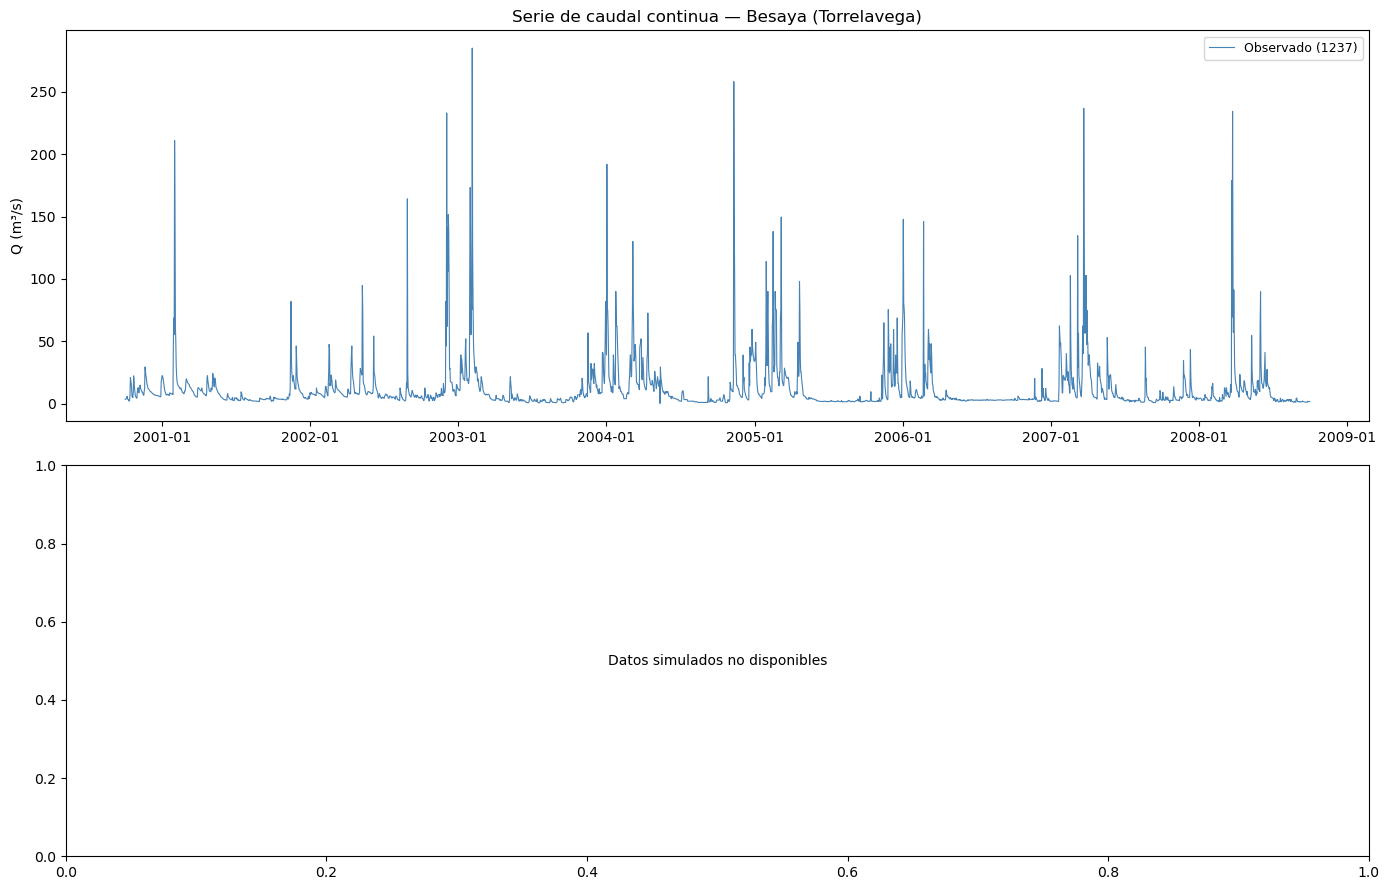

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
ax.plot(Q_obs.index, Q_obs.values, color='steelblue', lw=0.8, label='Observado (1237)')
if Q_sim is not None:
    ax.plot(Q_sim.index, Q_sim.values, color='tomato', lw=0.8, alpha=0.85, label='Simulado HMS')
ax.set(ylabel='Q (m³/s)', title='Serie de caudal continua — Besaya (Torrelavega)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Scatter obs vs sim
ax2 = axes[1]
if Q_sim is not None:
    common_idx = Q_obs.index.intersection(Q_sim.index)
    ax2.scatter(Q_obs.loc[common_idx], Q_sim.loc[common_idx],
                s=4, alpha=0.4, color='steelblue')
    lim = [0, max(Q_obs.max(), Q_sim.max()) * 1.05]
    ax2.plot(lim, lim, 'r--', lw=1)
    ax2.set(xlabel='Q observado (m³/s)', ylabel='Q simulado (m³/s)',
            title='Diagrama de dispersión obs vs sim')
else:
    ax2.text(0.5, 0.5, 'Datos simulados no disponibles',
             ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.savefig(OUT_DIR / 'calibration_plot.png', dpi=150)
plt.show()

## 6. Event extraction above threshold

In [9]:
# ── Cargar eventos pre-calculados desde los datos originales ──────────────────
EVENTOS_OBS  = DATA_ROOT / 'processed' / 'eventos_observados.csv'
EVENTOS_CLAS = DATA_ROOT / 'processed' / 'eventos_clasificados.csv'

if EVENTOS_OBS.exists():
    events_df = pd.read_csv(EVENTOS_OBS)
    print(f'Eventos observados pre-calculados: {len(events_df)}')
    print(events_df.describe().round(1))
else:
    # Calcular desde la serie de caudal con pyhydra
    print(f'Umbral P90 = {Q_threshold:.1f} m³/s')
    from pyhydra.climate.time_series.events import extract_discharge_events
    events_df = extract_discharge_events(Q_obs, threshold=Q_threshold, plot=False)
    events_df.to_csv(EVENTOS_OBS, index=False)
    print(f'Eventos extraídos y exportados: {len(events_df)}')

events_df.head()

Eventos observados pre-calculados: 224
       Inicio_evento  Fin_evento   Qmax   Qmed  Duracion  shape_type
count          224.0       224.0  224.0  224.0     224.0       224.0
mean          5541.9      5701.0  214.8   22.8     159.1         2.1
std           2933.9      2979.0  158.7   16.3     163.2         1.3
min             39.0        45.0   30.9    1.3       1.0         0.0
25%           3058.8      3311.0  104.3   10.6      55.8         0.0
50%           5213.5      5425.5  159.3   18.0     114.0         3.0
75%           7854.8      8045.8  258.2   30.8     233.8         3.0
max          10782.0     10784.0  647.8  100.7    1157.0         3.0


,Inicio_evento,Fin_evento,Qmax,Qmed,Duracion,shape_type
0,39,45,72.33,12.578571,6,0
1,138,139,30.90,28.070000,1,1
2,168,176,144.67,58.814444,8,2
3,175,178,163.00,100.662500,3,1
4,200,203,92.07,29.077500,3,0


In [ ]:
# Extraer episodios de lluvia concurrentes con los eventos de caudal
pma_file = PROC_DIR / 'pma_idw_daily.csv'
if pma_file.exists() and not events_df.empty:
    pma = pd.read_csv(pma_file, index_col=0, parse_dates=True).clip(lower=0)
    series_dict = {'Q_obs': Q_obs, 'PMA': pma.mean(axis=1)}

    # Normalise column names: events_df may use Inicio_evento/Fin_evento (legacy)
    # or start/end (new). Map to a consistent pair.
    col_start = 'start' if 'start' in events_df.columns else 'Inicio_evento'
    col_end   = 'end'   if 'end'   in events_df.columns else 'Fin_evento'

    if col_start in events_df.columns and col_end in events_df.columns:
        # Convert integer day offsets to date strings if needed
        Q_idx = Q_obs.index
        event_bounds = []
        for _, row in events_df.iterrows():
            try:
                i0, i1 = int(row[col_start]), int(row[col_end])
                if i0 < len(Q_idx) and i1 < len(Q_idx):
                    event_bounds.append((Q_idx[i0], Q_idx[i1]))
            except (ValueError, TypeError):
                pass

        if event_bounds:
            concurrent = extract_concurrent_events(event_bounds, series_dict, buffer_days=3)
            print(f'Episodios con datos de lluvia y caudal: {len(concurrent)}')

            ev_stats = []
            for ev in concurrent:
                q_ev = ev.get('Q_obs', pd.Series(dtype=float)).dropna()
                p_ev = ev.get('PMA',   pd.Series(dtype=float)).dropna()
                if q_ev.empty:
                    continue
                ev_stats.append({
                    'start':    q_ev.index[0],
                    'end':      q_ev.index[-1],
                    'Q_peak':   float(q_ev.max()),
                    'P_total':  float(p_ev.sum()) if not p_ev.empty else np.nan,
                    'duration': len(q_ev),
                })
            if ev_stats:
                events_concurrent_df = pd.DataFrame(ev_stats)
                events_concurrent_df.to_csv(OUT_DIR / 'eventos_caudal_lluvia.csv', index=False)
                print(events_concurrent_df.head())
            else:
                print('Sin episodios concurrentes extraíbles.')
        else:
            print('Sin índices de evento convertibles — revisar formato de eventos_observados.csv')
    else:
        print(f'Columnas de inicio/fin no encontradas. Columnas disponibles: {list(events_df.columns)}')
else:
    print('PMA no disponible o sin eventos — omitiendo extracción concurrente')


## 7. Event statistics — preparation for downscaling

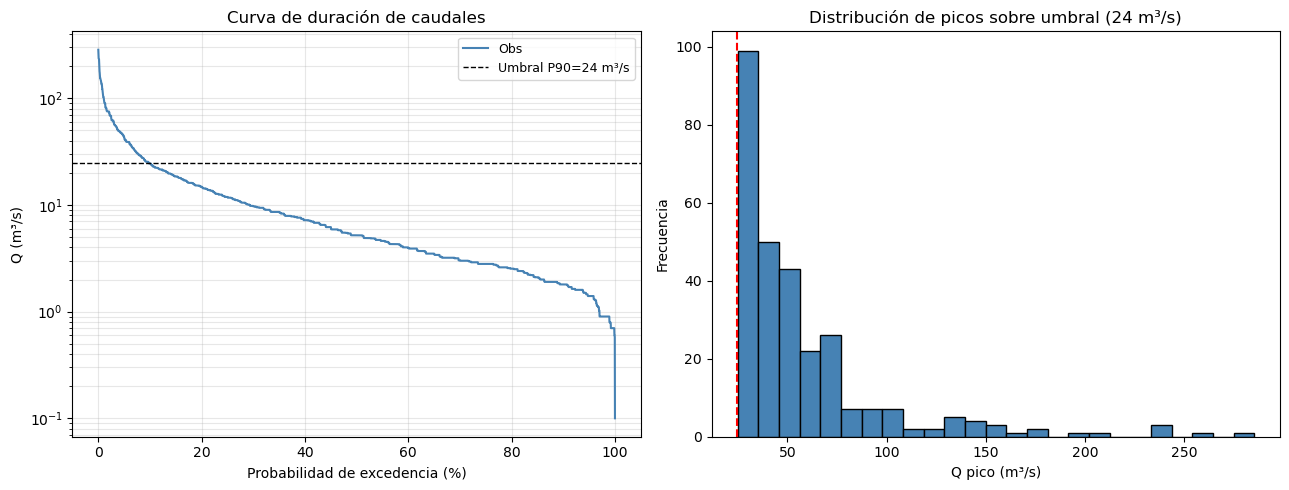

In [11]:
# Compute flow duration curve (FDC)
q_sorted = np.sort(Q_obs.dropna().values)[::-1]
exceedance = np.linspace(0, 100, len(q_sorted))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(exceedance, q_sorted, color='steelblue', lw=1.5, label='Obs')
if Q_sim is not None:
    q_sim_sorted = np.sort(Q_sim.reindex(Q_obs.index).dropna().values)[::-1]
    exc_sim = np.linspace(0, 100, len(q_sim_sorted))
    ax.semilogy(exc_sim, q_sim_sorted, color='tomato', lw=1.5, alpha=0.85, label='Sim')
ax.axhline(Q_threshold, color='k', ls='--', lw=1, label=f'Umbral P90={Q_threshold:.0f} m³/s')
ax.set(xlabel='Probabilidad de excedencia (%)', ylabel='Q (m³/s)',
       title='Curva de duración de caudales')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Histograma de caudales sobre umbral
ax = axes[1]
q_above = Q_obs[Q_obs > Q_threshold].values
if len(q_above) > 0:
    ax.hist(q_above, bins=25, color='steelblue', edgecolor='k')
ax.axvline(Q_threshold, color='r', lw=1.5, ls='--')
ax.set(xlabel='Q pico (m³/s)', ylabel='Frecuencia',
       title=f'Distribución de picos sobre umbral ({Q_threshold:.0f} m³/s)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fdc_eventos.png', dpi=150)
plt.show()